In [ ]:
# Load D1/D2/D3 and the label, and cap the number of threads KMeans uses
import os
os.environ["OMP_NUM_THREADS"] = "3"
# Prevents a known KMeans memory-leak warning on Windows by limiting OpenMP threads


import pandas as pd

D1 = pd.read_csv("D1.csv")
D2 = pd.read_csv("D2.csv")
D3 = pd.read_csv("D3.csv")
y = pd.read_csv("y_clean.csv").squeeze("columns")
# y is only loaded here to check clusters against the true labels afterward — never fed into K-Means

print("D1 shape:", D1.shape)
print("D2 shape:", D2.shape)
print("D3 shape:", D3.shape)
print("Legendary count:", y.sum(), "out of", len(y))

D1 shape: (721, 7)
D2 shape: (721, 7)
D3 shape: (721, 7)
Legendary count: 46 out of 721


In [ ]:
# Choose D3 (standard-scaled data) as the input for K-Means clustering
# Distance-based algorithms like K-Means are sensitive to feature scale, so the standardized
# version (mean 0, std 1) is used rather than the raw or min-max scaled data
cluster_data = D3.copy()
cluster_data.describe().loc[["mean", "std"]]

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
mean,-3.941985e-17,2.759389e-16,7.883969e-17,-8.869465e-17,-5.912977e-17,-5.912977e-17,2.266641e-16
std,1.000694e+00,1.000694e+00,1.000694e+00,1.000694e+00,1.000694e+00,1.000694e+00,1.000694e+00


In [ ]:
# Run K-Means for K = 2 through K = 10 and record Inertia and Silhouette Score for each
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []
for k in range(2, 11):
    # Runs K-Means 10 times with different centroid seeds and keeps the best result
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(cluster_data)
    inertia = km.inertia_
    sil = silhouette_score(cluster_data, labels)
    results.append({"K": k, "Inertia": inertia, "Silhouette": sil})

results_df = pd.DataFrame(results)
results_df

,K,Inertia,Silhouette
0,2,3176.817853,0.325940
1,3,2800.560101,0.232294
2,4,2488.665005,0.239002
3,5,2283.268777,0.246596
4,6,2142.709747,0.172326
5,7,2003.271112,0.167853
6,8,1904.396381,0.156601
7,9,1783.595592,0.168268
8,10,1703.162264,0.172496


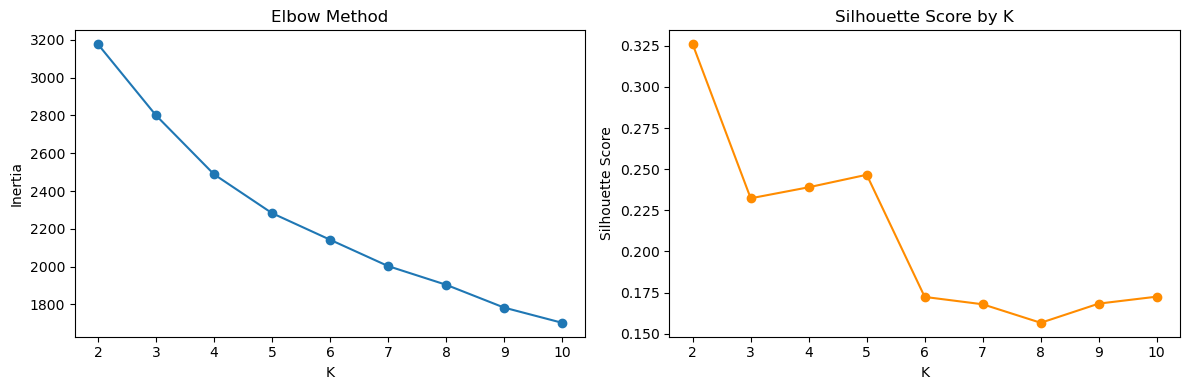

In [ ]:
# Plot the Elbow Method (Inertia) and Silhouette Score curves to help pick the best K
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot: look for the point where Inertia stops dropping sharply
axes[0].plot(results_df["K"], results_df["Inertia"], marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

# Silhouette plot: look for the K with the highest score (closest to 1)
axes[1].plot(results_df["K"], results_df["Silhouette"], marker="o", color="darkorange")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Select the best K as the one with the highest Silhouette Score
best_row = results_df.loc[results_df["Silhouette"].idxmax()]
best_k = int(best_row["K"])

print(f"Best K by silhouette score: {best_k} (silhouette = {best_row['Silhouette']:.4f})")

Best K by silhouette score: 2 (silhouette = 0.3259)


In [ ]:
# Fit the final K-Means model using the chosen best K and get cluster assignments
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_km.fit_predict(cluster_data)

# Show how many Pokemon fell into each cluster
print(f"Cluster sizes: {pd.Series(cluster_labels).value_counts().to_dict()}")

Cluster sizes: {0: 378, 1: 343}


In [ ]:
# Check how well the unsupervised clusters line up with the true Legendary label
# (this is purely for double checking, the label was never used to form the clusters)
check_df = pd.DataFrame({"cluster": cluster_labels, "legendary": y})
summary = check_df.groupby("cluster")["legendary"].agg(["count", "sum"])
summary.columns = ["Pokémon in cluster", "Actually Legendary"]
summary

,Pokémon in cluster,Actually Legendary
cluster,,
0,378,46
1,343,0


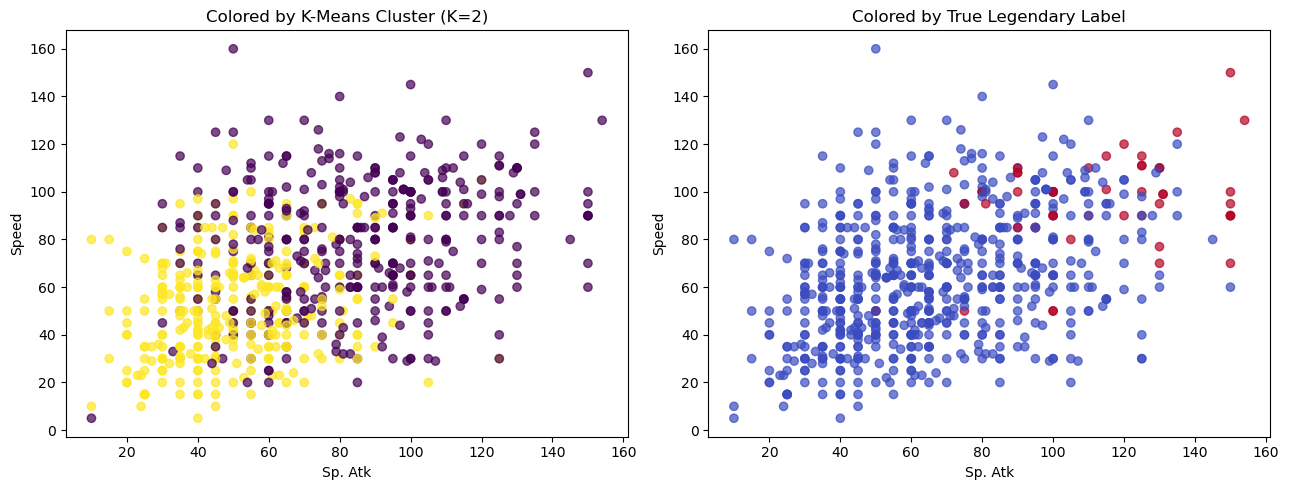

In [ ]:
# Scatter plot comparing K-Means clusters vs. the true Legendary labels on the same two features
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: points colored by which cluster K-Means assigned them to
axes[0].scatter(D1["Sp. Atk"], D1["Speed"], c=cluster_labels, cmap="viridis", alpha=0.7)
axes[0].set_xlabel("Sp. Atk")
axes[0].set_ylabel("Speed")
axes[0].set_title(f"Colored by K-Means Cluster (K={best_k})")

# Right plot: same two features, but colored by the actual ground-truth Legendary label
axes[1].scatter(D1["Sp. Atk"], D1["Speed"], c=y, cmap="coolwarm", alpha=0.7)
axes[1].set_xlabel("Sp. Atk")
axes[1].set_ylabel("Speed")
axes[1].set_title("Colored by True Legendary Label")

plt.tight_layout()
plt.savefig("clustering_scatter.png", dpi=150, bbox_inches="tight")
plt.show()